# AAX: Seminar 3

In this project, we implement a basic indoor localization system using unsupervised learning techniques. Specifically, we apply **K-means clustering** on Wi-Fi signal strength measurements (RSSI) to estimate the position of a device in an indoor environment.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import accuracy_score

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/Shareddrives/MLNETWORKS/SEMIS/S3/dataset_seminar3'


Mounted at /content/drive


# Part I: Data Preparation & Analysis



The dataset is made up of two parts:
- `rssi_data.csv`: Contains 1500 RSSI samples collected from three access points (AP1, AP2, and AP3).
- `labels_data.csv`: Includes the ground-truth labels showing the actual position of the device, ranging from 0 to 4.

In [ ]:
rssi_df   = pd.read_csv(
    os.path.join(BASE_PATH, 'rssi_data.csv'),
    header=None,
    names=['AP1','AP2','AP3']
)
labels_df = pd.read_csv(
    os.path.join(BASE_PATH, 'labels_data.csv'),
    header=None,
    names=['position']
)

print("RSSI shape:", rssi_df.shape)
print("Labels shape:", labels_df.shape)
rssi_df.head(), labels_df.head()

RSSI shape: (1500, 3)
Labels shape: (1500, 1)


(      AP1      AP2     AP3
 0 -21.949  -99.659 -42.257
 1 -34.049  -95.964 -47.779
 2 -18.861 -100.000 -34.175
 3 -53.497  -77.368 -67.360
 4 -54.986  -73.012 -69.780,
    position
 0         5
 1         4
 2         5
 3         2
 4         2)

2D scatter plots for each pair of access points (e.g., AP1 vs AP2).

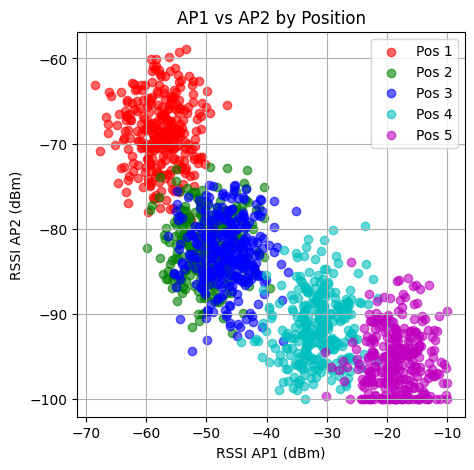

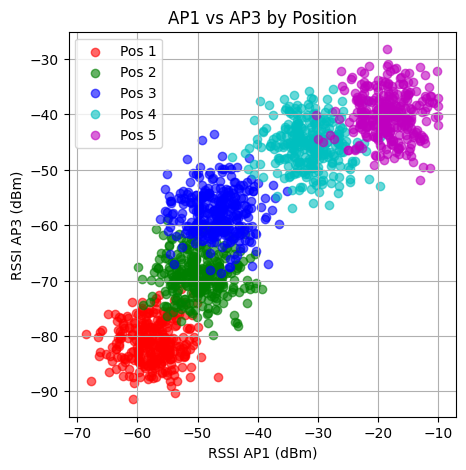

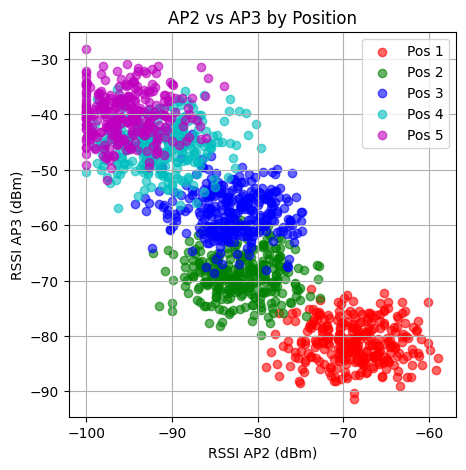

In [ ]:
colors    = ['r','g','b','c','m']
positions = sorted(labels_df['position'].unique())
pairs     = [('AP1','AP2'), ('AP1','AP3'), ('AP2','AP3')]

for xcol, ycol in pairs:
    plt.figure(figsize=(5,5))
    for p, c in zip(positions, colors):
        mask = labels_df['position'] == p
        plt.scatter(
            rssi_df[xcol][mask],
            rssi_df[ycol][mask],
            c=c,
            label=f'Pos {p}',
            alpha=0.6
        )
    plt.xlabel(f'RSSI {xcol} (dBm)')
    plt.ylabel(f'RSSI {ycol} (dBm)')
    plt.title(f'{xcol} vs {ycol} by Position')
    plt.legend()
    plt.grid(True)
    plt.show()


A 3D scatter plot to observe the spatial distribution of the RSSI vectors in three dimensions.

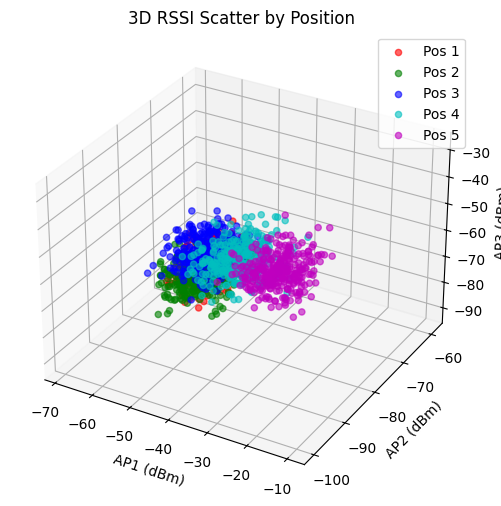

In [ ]:
fig = plt.figure(figsize=(6,6))
ax  = fig.add_subplot(111, projection='3d')

for p, c in zip(positions, colors):
    mask = labels_df['position'] == p
    ax.scatter(
        rssi_df['AP1'][mask],
        rssi_df['AP2'][mask],
        rssi_df['AP3'][mask],
        c=c,
        label=f'Pos {p}',
        alpha=0.6
    )

ax.set_xlabel('AP1 (dBm)')
ax.set_ylabel('AP2 (dBm)')
ax.set_zlabel('AP3 (dBm)')
ax.set_title('3D RSSI Scatter by Position')
ax.legend()
plt.show()


We can observe that:

- Position 5 (magentap) is fairly well separated from the others.
- Other positions show some overlap, especially between positions 2, 3, and 4.
- Overall, the clusters are somewhat distinguishable, but not linearly separable.

Summary Statistics per Position

AP1                  AP2                  AP3          
               mean       std       mean       std       mean       std
position                                                               
1        -57.547793  3.676167 -68.772187  4.041594 -81.156930  3.748209
2        -49.811667  3.892066 -81.979633  3.760133 -68.978473  3.869161
3        -46.740827  3.951756 -82.877667  3.981708 -57.633320  4.141495
4        -31.584760  4.058027 -91.492630  3.944587 -45.475647  4.102736
5        -18.477953  3.860880 -95.344790  3.531129 -40.081403  4.128701

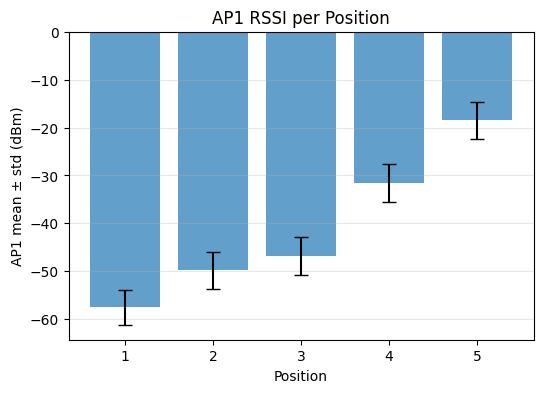

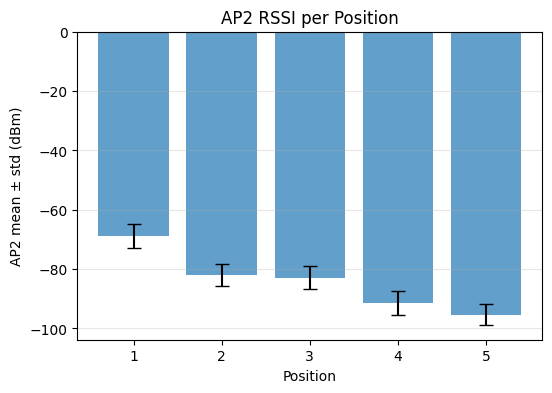

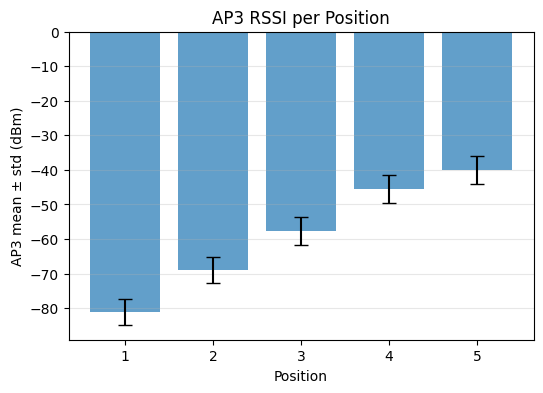

In [ ]:
# compute mean and std by position
stats = (
    rssi_df
    .join(labels_df)
    .groupby('position')
    .agg(['mean','std'])
)
display(stats)

# bar plots with error bars
for ap in ['AP1','AP2','AP3']:
    means = stats[ap]['mean']
    stds  = stats[ap]['std']
    plt.figure(figsize=(6,4))
    plt.bar(
        positions,
        means,
        yerr=stds,
        capsize=5,
        color='C0',
        alpha=0.7
    )
    plt.xticks(positions)
    plt.xlabel('Position')
    plt.ylabel(f'{ap} mean ± std (dBm)')
    plt.title(f'{ap} RSSI per Position')
    plt.grid(axis='y', alpha=0.3)
    plt.show()


We calculated the mean and standard deviation of the RSSI values for each access point and position. The results show that signal strength varies clearly across positions, especially for AP1 and AP3. This supports the idea that the data has enough structure for clustering.

# Part II: K-Means “From Scratch”

Initialization of Centroids

In [ ]:
# parameters
K        = 5
max_iter = 100
tol      = 1e-4

# data array
data     = rssi_df.values  # shape (P·M, 3)

# random init in feature-wise range
mins     = data.min(axis=0)
maxs     = data.max(axis=0)
centroids = np.random.uniform(mins, maxs, size=(K, 3))

print("Initial centroids:\n", centroids)


Initial centroids:
 [[-19.04417783 -62.24007478 -77.63896168]
 [-30.75440117 -89.79087639 -66.94591364]
 [-53.11324036 -88.48846844 -73.47093682]
 [-59.65477842 -92.96550827 -42.98340019]
 [-49.52129938 -77.46126902 -51.79137095]]


Iterations: Assignment & Update

In [ ]:
for it in range(max_iter):
    # 1) assignment
    dists    = np.linalg.norm(data[:, None, :] - centroids[None, :, :], axis=2)  # (N, K)
    labels_k = np.argmin(dists, axis=1)  # cluster index for each sample

    # 2) update
    new_centroids = np.array([
        data[labels_k == k].mean(axis=0) if np.any(labels_k == k)
        else np.random.uniform(mins, maxs)
        for k in range(K)
    ])

    # check convergence
    if np.allclose(new_centroids, centroids, atol=tol):
        print(f'Converged at iteration {it}')
        break

    centroids = new_centroids
else:
    print('Reached max iterations without full convergence')


Converged at iteration 14


Convergence check

In [ ]:
# After loop above, `labels_k` holds the final assignment
unique, counts = np.unique(labels_k, return_counts=True)
print("Final cluster counts:", dict(zip(unique, counts)))


Final cluster counts: {np.int64(0): np.int64(305), np.int64(1): np.int64(297), np.int64(2): np.int64(302), np.int64(3): np.int64(306), np.int64(4): np.int64(290)}


Cluster Visualization And Evaluation

Clustering accuracy (majority vote): 0.9587


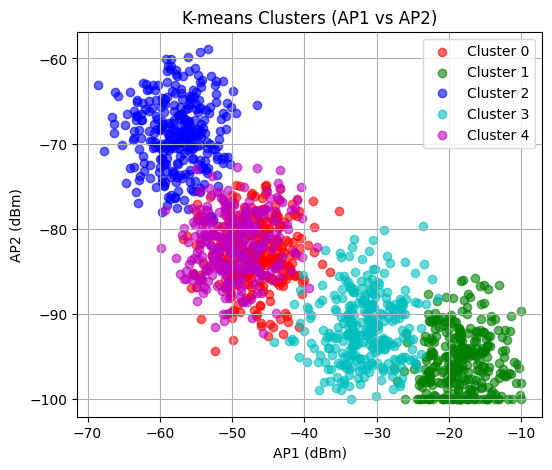

In [ ]:
from sklearn.metrics import accuracy_score

# 1) Map each cluster to the most frequent true position
cluster_to_pos = {}
for k in range(K):
    mask = (labels_k == k)
    if mask.any():
        # use pandas mode to find the most common label in this cluster
        most_common = labels_df['position'][mask].mode().iloc[0]
        cluster_to_pos[k] = most_common
    else:
        cluster_to_pos[k] = None

# 2) Build predicted positions array
pred_positions = np.array([cluster_to_pos[k] for k in labels_k])

# 3) Compute and print accuracy
acc = accuracy_score(labels_df['position'], pred_positions)
print(f'Clustering accuracy (majority vote): {acc:.4f}')

# 4) 2D scatter of the final clusters (AP1 vs AP2)
plt.figure(figsize=(6,5))
for k, c in zip(range(K), colors):
    mask = (labels_k == k)
    plt.scatter(
        data[mask, 0],
        data[mask, 1],
        c=c,
        label=f'Cluster {k}',
        alpha=0.6
    )
plt.xlabel('AP1 (dBm)')
plt.ylabel('AP2 (dBm)')
plt.title('K-means Clusters (AP1 vs AP2)')
plt.legend()
plt.grid(True)
plt.show()


After implementing K-means from scratch, we applied it to the RSSI data using 5 clusters.

The algorithm managed to separate the data quite well, and we obtained a clustering accuracy of **95.87%** using majority vote to match predicted clusters with ground-truth positions. This confirms that the RSSI patterns are distinctive enough for unsupervised learning.

<ipython-input-12-bbacd9d0e70d>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


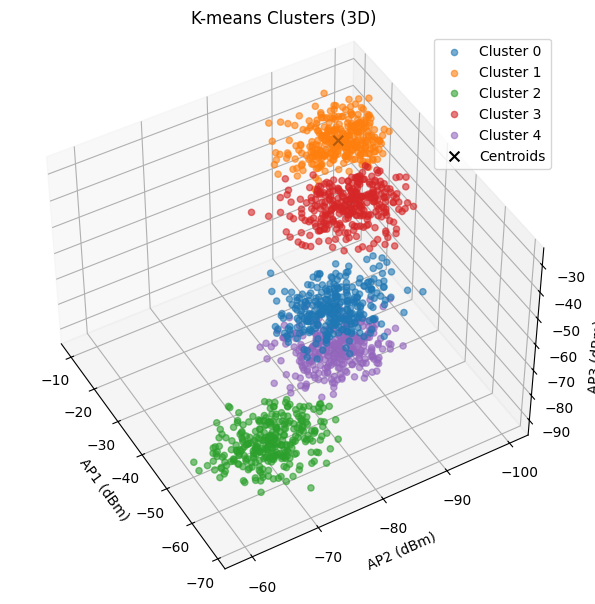

In [ ]:
# 3D scatter plot

import matplotlib.cm as cm
colors = cm.tab10.colors

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for k, c in zip(range(K), colors):
    mask = (labels_k == k)
    ax.scatter(
        data[mask, 0],  # AP1
        data[mask, 1],  # AP2
        data[mask, 2],  # AP3
        c=c,
        label=f'Cluster {k}',
        alpha=0.6
    )

# Centroids in 3D
ax.scatter(
    centroids[:, 0], centroids[:, 1], centroids[:, 2],
    c='black', s=50, marker='x', label='Centroids'
)
ax.view_init(elev=45, azim=150)
ax.set_xlabel('AP1 (dBm)')
ax.set_ylabel('AP2 (dBm)')
ax.set_zlabel('AP3 (dBm)')
ax.set_title('K-means Clusters (3D)')
ax.legend()
plt.tight_layout()
plt.show()

This shows the final clusters found by K-means using all three APs

We can clearly see that the clusters are well separated in space, confirming that RSSI values from multiple APs provide enough information to distinguish positions effectively.